# Soccer xG: EDA and modelling

Walk-through of the project: the StatsBomb shots, the features, the model and how it compares with StatsBomb's own xG.
The scripts (`scripts/download_data.py`, `train.py`, `analyze.py`) do the same at full scale; this notebook explains *why*.

Run `python scripts/download_data.py` first (about 5 minutes).

In [1]:
import sys
sys.path.insert(0, "../src")
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from soccer_xg import data, features, model, scene

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})
shots = data.load_shots()
print(f"{len(shots):,} shots, {shots['is_goal'].sum():,} goals, {shots['match_id'].nunique():,} matches")
shots[["competition", "season", "team", "player", "x", "y", "body_part", "shot_type", "outcome", "statsbomb_xg"]].head()

100,864 shots, 11,086 goals, 3,961 matches


,competition,season,team,player,x,y,body_part,shot_type,outcome,statsbomb_xg
0,1. Bundesliga,2023/2024,Bayer Leverkusen,Borja Iglesias Quintas,107.0,53.4,Right Foot,Open Play,Off T,0.084877
1,1. Bundesliga,2023/2024,Bayer Leverkusen,Granit Xhaka,96.5,39.9,Right Foot,Open Play,Blocked,0.042399
2,1. Bundesliga,2023/2024,Bayer Leverkusen,Adam Hložek,88.2,45.5,Right Foot,Open Play,Blocked,0.017574
3,1. Bundesliga,2023/2024,Bayer Leverkusen,Alejandro Grimaldo García,98.5,49.2,Left Foot,Free Kick,Saved,0.075614
4,1. Bundesliga,2023/2024,Bayer Leverkusen,Borja Iglesias Quintas,111.2,37.8,Head,Open Play,Saved,0.118389


## 1. Where goals come from

Goal rate falls steeply with distance; headers convert worse than shots with the foot at the same distance.

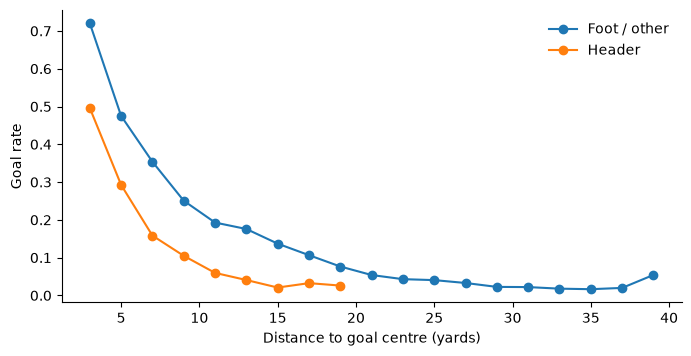

In [2]:
np_shots = shots[shots["shot_type"] != "Penalty"].copy()
np_shots["distance"] = np.hypot(120 - np_shots["x"], 40 - np_shots["y"])
np_shots["body"] = np.where(np_shots["body_part"] == "Head", "Header", "Foot / other")
rate = (np_shots.assign(band=pd.cut(np_shots["distance"], range(0, 41, 2)))
        .groupby(["band", "body"], observed=True)["is_goal"].agg(["mean", "size"]).reset_index())
fig, ax = plt.subplots(figsize=(8, 3.8))
for body, g in rate[rate["size"] >= 50].groupby("body"):
    ax.plot([b.mid for b in g["band"]], g["mean"], "o-", label=body)
ax.set_xlabel("Distance to goal centre (yards)"); ax.set_ylabel("Goal rate"); ax.legend(frameon=False)
plt.show()

## 2. Who is in the way

The freeze frame tells us how many defenders stand in the shooting cone (the triangle from ball to posts). Each one costs a lot.

In [3]:
f = features.shot_features(np_shots.sample(30000, random_state=0))
f["is_goal"] = np_shots.loc[f.index, "is_goal"]
f["close"] = f["distance"] < 18
print(f.groupby(["close", f["n_opponents_in_cone"].clip(upper=4)])["is_goal"].agg(["mean", "size"]).round(3))

                            mean  size
close n_opponents_in_cone             
False 0                    0.053  6001
      1                    0.031  5852
      2                    0.028  2046
      3                    0.060   907
      4                    0.057   566
True  0                    0.213  8275
      1                    0.115  4340
      2                    0.098  1373
      3                    0.075   439
      4                    0.030   201


Close in, every extra defender in the cone cuts the goal rate. From long range, 3–4 "defenders" in the cone score *more* often than 1–2: those are mostly **free kicks**, where the players in the cone are the wall and the shooters are set-piece specialists. The model sees `shot_type`, so it can separate the two.

## 3. Split by match, then model

Shots in one match share players, weather and game state, so the split is by match, within every competition-season.

In [4]:
train_idx, test_idx = model.train_test_matches(shots)
train, test = shots.loc[train_idx], shots.loc[test_idx]
baseline = model.DistanceAngleBaseline().fit(train)
fitted = model.fit_xg_model(train)
mask = ~model.is_penalty(test)
pd.DataFrame({
    "Distance + angle": model.score(test["is_goal"][mask], baseline.predict(test)[mask]),
    "LightGBM (this project)": model.score(test["is_goal"][mask], fitted.predict(test)[mask]),
    "StatsBomb xG": model.score(test["is_goal"][mask], test["statsbomb_xg"][mask]),
}).T.round(4)

  grouped 5-fold CV: 267 rounds, log loss 0.2628


,log_loss,brier,roc_auc,ece,goals,xg,n
Distance + angle,0.2939,0.0836,0.7387,0.0122,2105.0,2094.4826,20552.0
LightGBM (this project),0.2604,0.0746,0.8157,0.0045,2105.0,2110.7946,20552.0
StatsBomb xG,0.2640,0.0751,0.8094,0.0109,2105.0,1983.8330,20552.0


## 4. Sanity checks the metrics can't give

A model can score well and still behave oddly in rare places. Scoring a grid of simple scenes shows whether xG falls with distance and width everywhere.
Before the monotonic constraints and the keeper-distance cap (see `model.MONOTONE` and `features.KEEPER_NEAR`), shots from the touchline scored *higher* than central ones.

In [5]:
grid = pd.DataFrame({x: [fitted.predict(scene.scene_to_shot((x, y)))[0] for y in (2, 10, 20, 30, 40)]
                     for x in (85, 95, 105, 112)}, index=["y=2 (touchline)", "y=10", "y=20", "y=30", "y=40 (central)"])
grid.round(3)

,85,95,105,112
y=2 (touchline),0.031,0.047,0.060,0.060
y=10,0.031,0.047,0.060,0.060
y=20,0.031,0.047,0.065,0.066
y=30,0.031,0.062,0.179,0.247
y=40 (central),0.032,0.097,0.298,0.586


## 5. What drives a single shot

LightGBM gives exact per-shot contributions (TreeSHAP), the same breakdown the app shows.

In [6]:
shot = scene.scene_to_shot((108, 34), defenders=[(113, 37)], assist="Cut-back")
print(f"xG = {fitted.predict(shot)[0]:.3f}")
scene.contributions(fitted, shot).drop("baseline").sort_values(key=abs, ascending=False).head(8).round(3)

xG = 0.149


angle                        0.616
nearest_opponent_distance    0.396
gk_distance_to_shooter      -0.267
gk_offset_from_shot_line    -0.178
distance                     0.173
n_opponents_in_cone         -0.163
body_part                    0.150
x                            0.118
dtype: float64

## 6. Next

`scripts/analyze.py` computes out-of-fold xG for every shot and the finishing analyses: is beating xG repeatable, and how much of Messi's over-performance survives a team adjustment?
The report (`report/report.html`) and the app's *Finishing* page present them.